# Import Libraries  

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load Dataset

In [3]:

df = pd.read_csv("AI_Impact_on_Jobs_2030.csv", delimiter=',')

print("df: ", df)
print("df.head():  ", df.head())
print("df.info() : ", df.info())
print("df.describe(): ", df.describe())
print("df.shape:  ", df.shape)
print("df.columns: ", df.columns)
df.isnull().sum()
df.duplicated().sum()


df:                  Job_Title  Average_Salary  Years_Experience Education_Level  \
0          Security Guard           45795                28        Master's   
1      Research Scientist          133355                20             PhD   
2     Construction Worker          146216                 2     High School   
3       Software Engineer          136530                13             PhD   
4       Financial Analyst           70397                22     High School   
...                   ...             ...               ...             ...   
2995               Doctor          111319                 6      Bachelor's   
2996        UX Researcher           44363                29             PhD   
2997       Data Scientist           61325                23        Master's   
2998     Graphic Designer          110296                 7             PhD   
2999     Graphic Designer          123909                25             PhD   

      AI_Exposure_Index  Tech_Growth_Factor  A

np.int64(0)

# Numpy Operations

In [4]:
salary = np.array(df['Average_Salary'].dropna())

print("Average Salary Mean         : ", np.mean(salary))
print("Average Salary Average      : ", np.average(salary))
print("Average Salary Std          : ", np.std(salary))
print("Average Salary Median       : ", np.median(salary))
print("Average Salary Percentile 25: ", np.percentile(salary, 25))
print("Average Salary Percentile 75: ", np.percentile(salary, 75))
print("Average Salary Percentile 3 : ", np.percentile(salary, 3))
print("Average Salary Min          : ", np.min(salary))
print("Average Salary Max          : ", np.max(salary))


Average Salary Mean         :  89372.279
Average Salary Average      :  89372.279
Average Salary Std          :  34602.32027138969
Average Salary Median       :  89318.0
Average Salary Percentile 25:  58640.0
Average Salary Percentile 75:  119086.5
Average Salary Percentile 3 :  33983.7
Average Salary Min          :  30030
Average Salary Max          :  149798


# Seaborn Graphs

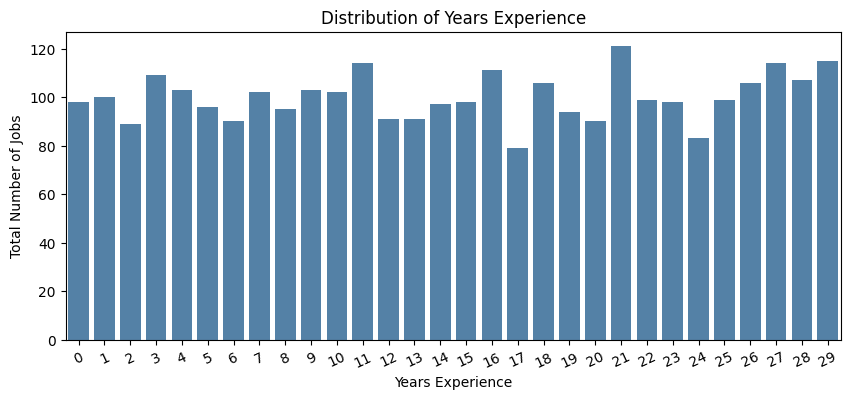

C:\Users\Hp\AppData\Local\Temp\ipykernel_1720\1896864652.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='AI_Exposure_Bin', y='Average_Salary', data=df,


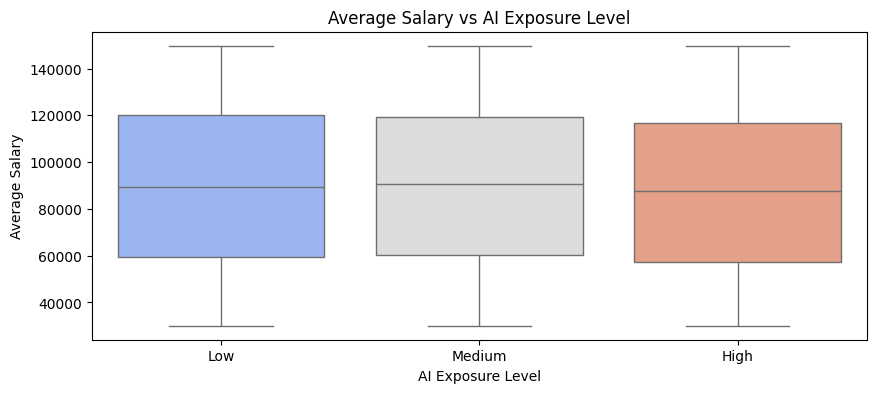

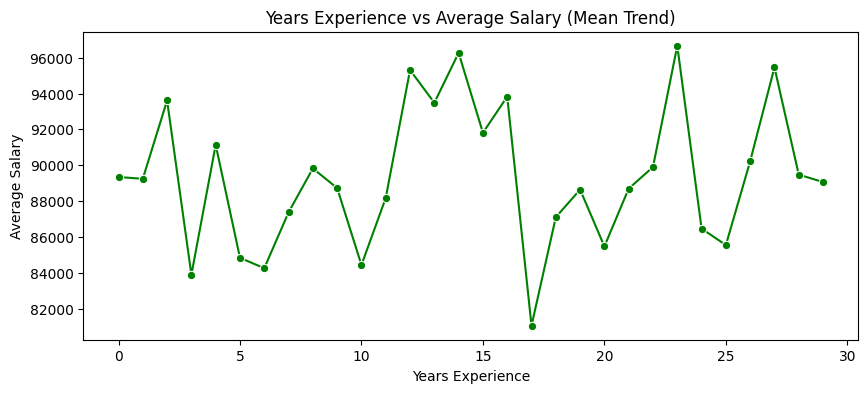

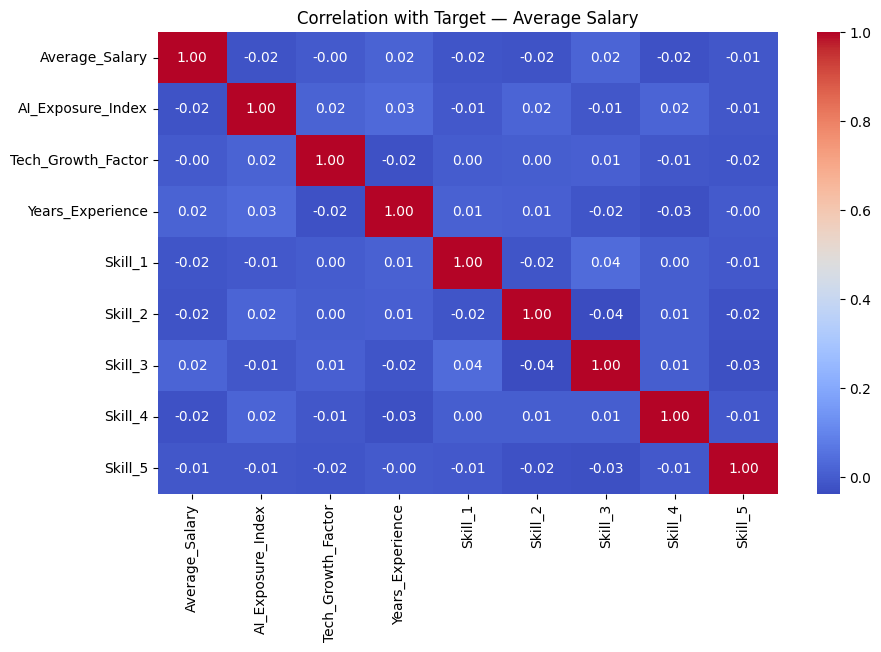

In [ ]:
# 1. COUNTPLOT — Years Experience distribution
plt.figure(figsize=(10,4))
sns.countplot(data=df, x='Years_Experience', color='steelblue')
plt.title("Distribution of Years Experience")
plt.xlabel("Years Experience")
plt.ylabel("Total Number of Jobs")
plt.xticks(rotation=25)
plt.show()

#boxplot
df['AI_Exposure_Bin'] = pd.cut(df['AI_Exposure_Index'],
                                bins=3,
                                labels=['Low','Medium','High'])

plt.figure(figsize=(10,4))
sns.boxplot(x='AI_Exposure_Bin', y='Average_Salary', data=df,
            order=['Low','Medium','High'], palette='coolwarm')
plt.title("Average Salary vs AI Exposure Level")
plt.xlabel("AI Exposure Level")
plt.ylabel("Average Salary")
plt.show()

#lineplot
salary_by_exp = df.groupby('Years_Experience')['Average_Salary'].mean().reset_index()

plt.figure(figsize=(10,4))
sns.lineplot(x='Years_Experience', y='Average_Salary',
             data=salary_by_exp, color='green', marker='o')
plt.title("Years Experience vs Average Salary (Mean Trend)")
plt.xlabel("Years Experience")
plt.ylabel("Average Salary")
plt.show()

cols = ['Average_Salary', 'AI_Exposure_Index', 'Tech_Growth_Factor',
        'Years_Experience', 'Skill_1', 'Skill_2', 'Skill_3',
        'Skill_4', 'Skill_5']

plt.figure(figsize=(10,6))
sns.heatmap(df[cols].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation with Target — Average Salary")
plt.show()



# Train Test Split and 3 models Applied

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Take 8 features 
X = df[['AI_Exposure_Index', 'Tech_Growth_Factor',
        'Years_Experience', 'Skill_1', 'Skill_2',
        'Skill_3', 'Skill_4', 'Skill_5']]

# target is Average Salary
y = df['Average_Salary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)


# LINEAR REGRESSION
regressor = LinearRegression()
regressor.fit(X_train, y_train)

print("=" * 50)
print("V2 — LINEAR REGRESSION")
print("=" * 50)
print("Intercept:\n", regressor.intercept_)

feature_names = ['AI_Exposure_Index', 'Tech_Growth_Factor',
                 'Years_Experience', 'Skill_1', 'Skill_2',
                 'Skill_3', 'Skill_4', 'Skill_5']

coefficients_df = pd.DataFrame(data=regressor.coef_,
                                index=feature_names,
                                columns=['Coefficient value'])
print(coefficients_df)

y_pred_lr = regressor.predict(X_test)
results_lr = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_lr})
print("Actual vs Predicted:\n", results_lr)

mae  = mean_absolute_error(y_test, y_pred_lr)
mse  = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
actual_minus_predicted   = sum((y_test - y_pred_lr)**2)
actual_minus_actual_mean = sum((y_test - y_test.mean())**2)
r2 = 1 - actual_minus_predicted / actual_minus_actual_mean

print(f'MAE  : {mae:.2f}')
print(f'MSE  : {mse:.2f}')
print(f'RMSE : {rmse:.2f}')
print(f'R²   : {r2:.4f}')

# RIDGE REGRESSION
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

print("\n" + "=" * 50)
print("V2 — RIDGE REGRESSION")
print("=" * 50)
print("Intercept:\n", ridge.intercept_)

ridge_coef_df = pd.DataFrame(data=ridge.coef_,
                              index=feature_names,
                              columns=['Coefficient value'])
print(ridge_coef_df)

y_pred_ridge = ridge.predict(X_test)
results_ridge = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_ridge})
print("Actual vs Predicted:\n", results_ridge)

mae  = mean_absolute_error(y_test, y_pred_ridge)
mse  = mean_squared_error(y_test, y_pred_ridge)
rmse = np.sqrt(mse)
actual_minus_predicted   = sum((y_test - y_pred_ridge)**2)
actual_minus_actual_mean = sum((y_test - y_test.mean())**2)
r2 = 1 - actual_minus_predicted / actual_minus_actual_mean

print(f'MAE  : {mae:.2f}')
print(f'MSE  : {mse:.2f}')
print(f'RMSE : {rmse:.2f}')
print(f'R²   : {r2:.4f}')

# LASSO REGRESSION
lasso = Lasso(alpha=0.001, max_iter=10000)
lasso.fit(X_train, y_train)

print("\n" + "=" * 50)
print("V2 — LASSO REGRESSION")
print("=" * 50)
print("Intercept:\n", lasso.intercept_)

lasso_coef_df = pd.DataFrame(data=lasso.coef_,
                              index=feature_names,
                              columns=['Coefficient value'])
print(lasso_coef_df)

y_pred_lasso = lasso.predict(X_test)
results_lasso = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_lasso})
print("Actual vs Predicted:\n", results_lasso)

mae  = mean_absolute_error(y_test, y_pred_lasso)
mse  = mean_squared_error(y_test, y_pred_lasso)
rmse = np.sqrt(mse)
actual_minus_predicted   = sum((y_test - y_pred_lasso)**2)
actual_minus_actual_mean = sum((y_test - y_test.mean())**2)
r2 = 1 - actual_minus_predicted / actual_minus_actual_mean

print(f'MAE  : {mae:.2f}')
print(f'MSE  : {mse:.2f}')
print(f'RMSE : {rmse:.2f}')
print(f'R²   : {r2:.4f}')



MAE: 30,371 | RMSE: 34,902


# Observations:

# All three models produced nearly identical results
# Predicted values clustered around the mean (~89,000) regardless of actual values
# R² of 0.0005 indicates the model explains less than 0.1% of variance in salary

# Reason for Low Accuracy:

# Correlation heatmap confirmed that no feature has correlation greater than 0.04 with Average_Salary
# So there is no real world relationship between features and target

V2 — LINEAR REGRESSION
Intercept:
 89288.23708333333
                    Coefficient value
AI_Exposure_Index         -597.005212
Tech_Growth_Factor         149.656064
Years_Experience           617.513997
Skill_1                   -903.079695
Skill_2                   -808.715317
Skill_3                    280.994121
Skill_4                   -928.249896
Skill_5                   -112.669584
Actual vs Predicted:
       Actual     Predicted
1801  146298  87907.987193
1190  134042  86471.704096
1817   64118  89127.932739
251   105831  91100.914713
2505   73489  86240.215697
...      ...           ...
104    47087  90513.791066
2087  115780  90139.871482
599    74440  90022.847790
1756   32414  88839.886167
1323  145070  90369.792515

[600 rows x 2 columns]
MAE  : 30371.42
MSE  : 1218198339.01
RMSE : 34902.70
R²   : 0.0005

V2 — RIDGE REGRESSION
Intercept:
 89288.23708333333
                    Coefficient value
AI_Exposure_Index         -596.756528
Tech_Growth_Factor         149.592373
Y

# Findings

In [ ]:
# Version 2 — REGRESSION ANALYSIS (Average Salary as Target)

# I have taken 4 Features: AI_Exposure_Index, Tech_Growth_Factor,
# Years_Experience, Skill_1 to Skill_5
# Target: Average_Salary (continuous)

# All three models produced identical results:
# Linear, Ridge, Lasso → R²: 0.0005, MAE: 30,371, RMSE: 34,902

# Root cause: Correlation heatmap confirmed no feature
# has correlation greater than 0.04 with Average_Salary
# Dataset is synthetic as there is no pattern that exists
# between selected features and salary